In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


In [2]:
df = pd.read_csv("../../Weekend Project/Project 2/loan_default_dataset.csv")

print(f"raw dataset shape: {df.shape}")
print(df.head())

raw dataset shape: (6015, 13)
   age  annual_income  credit_score  loan_amount  loan_term_months  \
0   59        79000.0         685.0      36100.0                36   
1   48        92900.0         476.0      10900.0                24   
2   34        42000.0         685.0       6400.0                48   
3   67        25400.0         620.0       9300.0                36   
4   24        31300.0         518.0      14000.0                48   

   interest_rate  debt_to_income  employment_length_years  num_open_accounts  \
0          11.62            20.4                      6.4                  5   
1          16.02             0.0                     10.1                  7   
2           9.03             NaN                      1.5                  4   
3          11.30            19.9                     12.9                  2   
4          12.57            45.3                      0.3                  8   

   num_late_payments_2yrs home_ownership             purpose  defaul

In [3]:
df_clean = df.copy()


df_clean["home_ownership"] = df_clean["home_ownership"].str.upper().str.strip()
df_clean["purpose"] = df_clean["purpose"].str.lower().str.strip()

df_clean.loc[(df_clean["age"] < 18) | (df_clean["age"] > 100), "age"] = np.nan

numeric_cols = [
    "age", "annual_income", "credit_score", "loan_amount",
    "loan_term_months", "interest_rate", "debt_to_income",
    "employment_length_years", "num_open_accounts", "num_late_payments_2yrs"
]
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

df_encoded = pd.get_dummies(df_clean, columns=["home_ownership", "purpose"], dtype=int)

print(f"cleaned and encoded shape: {df_encoded.shape}")

cleaned and encoded shape: (6015, 21)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

TARGET = "default"
X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# fit scaler only on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train_scaled.shape}")
print(f"X_test : {X_test_scaled.shape}")

X_train: (4812, 20)
X_test : (1203, 20)


In [5]:

X_train_tensor = torch.FloatTensor(X_train_scaled.copy())
y_train_tensor = torch.LongTensor(y_train.values.copy())

X_test_tensor = torch.FloatTensor(X_test_scaled.copy())
y_test_tensor = torch.LongTensor(y_test.values.copy())

print(f"X_train_tensor shape: {X_train_tensor.shape}, dtype: {X_train_tensor.dtype}")
print(f"y_train_tensor shape: {y_train_tensor.shape}, dtype: {y_train_tensor.dtype}")
print(f"\nsample tensor row:\n{X_train_tensor[0]}")

X_train_tensor shape: torch.Size([4812, 20]), dtype: torch.float32
y_train_tensor shape: torch.Size([4812]), dtype: torch.int64

sample tensor row:
tensor([ 1.7098,  0.3044, -1.1211, -0.7316, -1.1405,  1.5861,  1.1423,  3.0817,
         2.4176,  0.1354,  1.2805, -0.4691, -0.8878, -0.5405,  1.4363, -0.3655,
        -0.3306, -0.2949, -0.2873, -0.2844])


In [6]:
class LoanDefaultMLP(nn.Module):
    def __init__(self, input_size):
        super(LoanDefaultMLP, self).__init__()
        # input layer -> hidden layer
        self.layer1 = nn.Linear(input_size, 32)
        self.relu = nn.ReLU()
        # hidden layer -> hidden layer
        self.layer2 = nn.Linear(32, 16)
        # output layer -> 2 classes (default / no default)
        self.output = nn.Linear(16, 2)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.output(x)
        return x

input_size = X_train_tensor.shape[1]
model = LoanDefaultMLP(input_size)
print(model)

LoanDefaultMLP(
  (layer1): Linear(in_features=20, out_features=32, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=32, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=2, bias=True)
)


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("loss function: CrossEntropyLoss")
print("optimizer: Adam, learning rate=0.001")

loss function: CrossEntropyLoss
optimizer: Adam, learning rate=0.001


In [8]:
epochs = 20
loss_history = []

for epoch in range(epochs):
   
    optimizer.zero_grad()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [1/20], Loss: 0.6863
Epoch [2/20], Loss: 0.6791
Epoch [3/20], Loss: 0.6719
Epoch [4/20], Loss: 0.6648
Epoch [5/20], Loss: 0.6577
Epoch [6/20], Loss: 0.6507
Epoch [7/20], Loss: 0.6437
Epoch [8/20], Loss: 0.6368
Epoch [9/20], Loss: 0.6299
Epoch [10/20], Loss: 0.6231
Epoch [11/20], Loss: 0.6162
Epoch [12/20], Loss: 0.6095
Epoch [13/20], Loss: 0.6027
Epoch [14/20], Loss: 0.5959
Epoch [15/20], Loss: 0.5892
Epoch [16/20], Loss: 0.5826
Epoch [17/20], Loss: 0.5759
Epoch [18/20], Loss: 0.5693
Epoch [19/20], Loss: 0.5627
Epoch [20/20], Loss: 0.5562


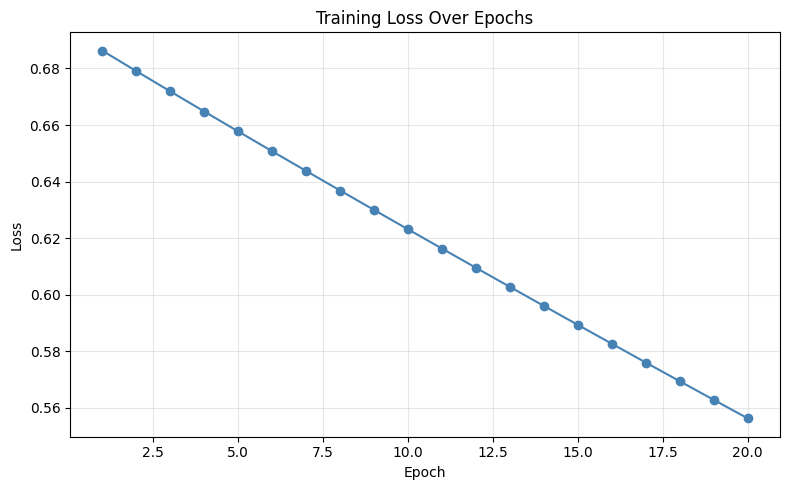

loss curve saved — confirms convergence


In [9]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), loss_history, marker="o", color="steelblue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss_curve.png")
plt.show()
print("loss curve saved — confirms convergence")

In [10]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, predicted = torch.max(test_outputs, 1)
    accuracy = (predicted == y_test_tensor).float().mean()

print(f"Test Accuracy: {accuracy.item():.4f}")

Test Accuracy: 0.8313


In [11]:
explanation = """
=== ReLU vs Sigmoid ===

Sigmoid:
- Output range: (0, 1)
- Large input values produce very small gradients.
- Causes the vanishing gradient problem, making deep
  networks learn slowly.

ReLU:
- Output range: [0, infinity)
- Gradient is 1 for positive inputs.
- Helps gradients flow easily and speeds up training.

Although ReLU may create dead neurons for negative inputs,
it is still the preferred choice for training deep networks.
"""
print(explanation)


=== ReLU vs Sigmoid ===

Sigmoid:
- Output range: (0, 1)
- Large input values produce very small gradients.
- Causes the vanishing gradient problem, making deep
  networks learn slowly.

ReLU:
- Output range: [0, infinity)
- Gradient is 1 for positive inputs.
- Helps gradients flow easily and speeds up training.

Although ReLU may create dead neurons for negative inputs,
it is still the preferred choice for training deep networks.



In [12]:
comparison = """
=== NumPy Arrays vs PyTorch Tensors ===

NumPy Array:
- Used for numerical calculations on the CPU.
- Does not track operations or compute gradients.

PyTorch Tensor:
- Similar to a NumPy array but supports autograd.
- Automatically computes gradients using .backward().
- Can run on both CPU and GPU for faster computation.

PyTorch tensors are ideal for building and training
deep learning models.
"""
print(comparison)


=== NumPy Arrays vs PyTorch Tensors ===

NumPy Array:
- Used for numerical calculations on the CPU.
- Does not track operations or compute gradients.

PyTorch Tensor:
- Similar to a NumPy array but supports autograd.
- Automatically computes gradients using .backward().
- Can run on both CPU and GPU for faster computation.

PyTorch tensors are ideal for building and training
deep learning models.

